In [28]:
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


loop over the sessions to find session with at least 10 grid cells 

In [ ]:
# there are all the sessions
mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              22: [33,34,35,36,37,38,39,40,41],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

n_grids = 0
n_non_grids = 0
n_cells = 0
for mouse, days in mouse_days.items():
    for day in days:
        gcs, ngs, all = classify_cells_both_sessions(mouse, day, percentile_threshold=95, source_path=None, verbose=False)  
        n_grids += len(gcs)
        n_non_grids += len(ngs)
        n_cells += len(all)
        
        if len(gcs)>10:
            print(f"Mouse {mouse}, Day {day}: {len(gcs)} grid cells, {len(ngs)} non-grid spatial cells")

In [ ]:
"""
Output gives 

Mouse 20, Day 16: 11 grid cells, 165 non-grid spatial cells
Mouse 20, Day 25: 16 grid cells, 18 non-grid spatial cells
Mouse 21, Day 16: 22 grid cells, 172 non-grid spatial cells
Mouse 21, Day 21: 53 grid cells, 131 non-grid spatial cells
Mouse 21, Day 26: 35 grid cells, 107 non-grid spatial cells
Mouse 25, Day 18: 11 grid cells, 111 non-grid spatial cells
Mouse 25, Day 19: 13 grid cells, 37 non-grid spatial cells
Mouse 25, Day 20: 20 grid cells, 31 non-grid spatial cells
Mouse 25, Day 21: 23 grid cells, 24 non-grid spatial cells
Mouse 25, Day 22: 17 grid cells, 142 non-grid spatial cells
Mouse 25, Day 24: 26 grid cells, 34 non-grid spatial cells
Mouse 25, Day 25: 44 grid cells, 49 non-grid spatial cells
Mouse 26, Day 18: 16 grid cells, 33 non-grid spatial cells
Mouse 26, Day 19: 47 grid cells, 213 non-grid spatial cells
Mouse 27, Day 23: 14 grid cells, 64 non-grid spatial cells
Mouse 28, Day 19: 19 grid cells, 79 non-grid spatial cells
Mouse 28, Day 23: 13 grid cells, 106 non-grid spatial cells
Mouse 28, Day 25: 30 grid cells, 81 non-grid spatial cells
Mouse 29, Day 19: 15 grid cells, 70 non-grid spatial cells
Mouse 29, Day 20: 17 grid cells, 172 non-grid spatial cells
Mouse 29, Day 23: 27 grid cells, 120 non-grid spatial cells
Mouse 29, Day 25: 12 grid cells, 154 non-grid spatial cells
"""

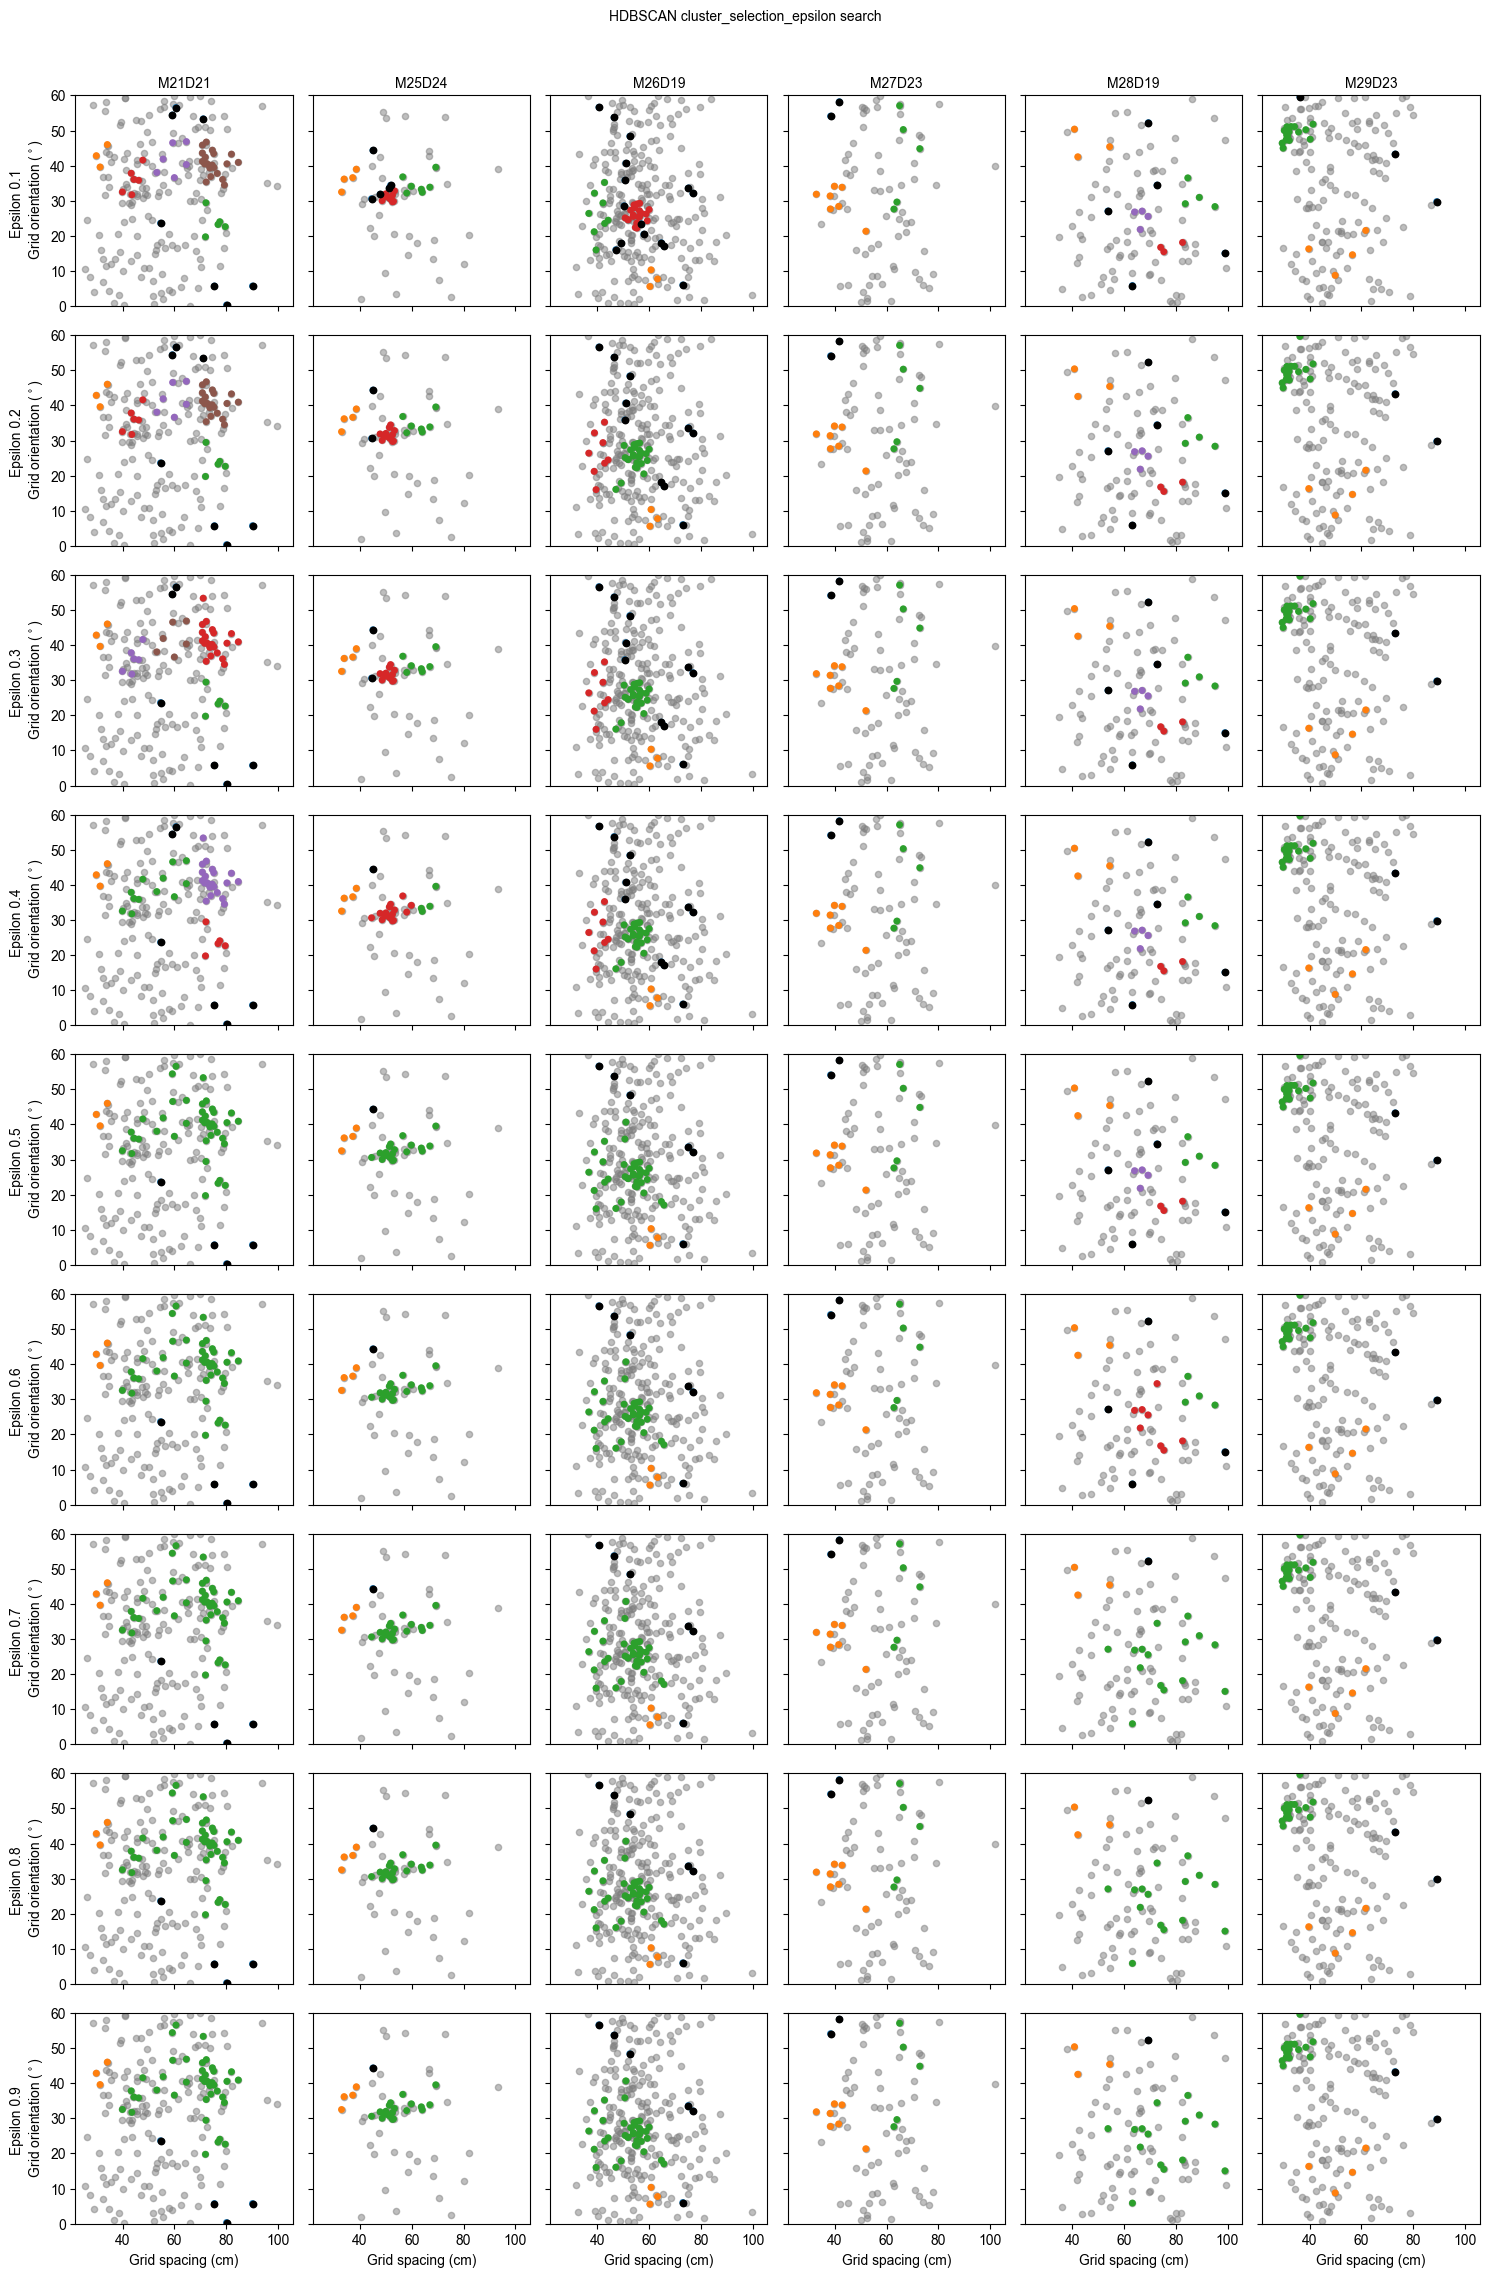

In [20]:
mouse_days_to_plot = {
    21: [21],
    25: [24],
    26: [19],
    27: [23],
    28: [19],
    29: [23],
}

epsilons = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Pre-load gcs/all once per session (avoids re-classifying for every epsilon)
session_data = {}
for mouse, days in mouse_days_to_plot.items():
    for day in days:
        gcs, ngs, all_cells = classify_cells_both_sessions(mouse, day, percentile_threshold=95, verbose=False)
        session_data[(mouse, day)] = (gcs, all_cells)

n_sessions = len(session_data)
n_eps = len(epsilons)

fig, axes = plt.subplots(nrows=n_eps, ncols=n_sessions, sharex=True, sharey=True,
                         figsize=(2.5 * n_sessions, 2.5 * n_eps), squeeze=False)

for row, eps in enumerate(epsilons):
    for col, (mouse, day) in enumerate(session_data.keys()):
        gcs, all_cells = session_data[(mouse, day)]
        ax = axes[row, col]
        HDBSCAN_grid_modules(
            gcs, all_cells,
            mouse=mouse, day=day,
            figpath='',
            cluster_selection_epsilon=eps,
            curate_with_vr=False,
            curate_with_brain_region=False,
            verbose=False,
            ax=ax,
        )
        if row == 0:
            ax.set_title(f'M{mouse}D{day}', fontsize=10)
        if row == n_eps - 1:
            ax.set_xlabel(f'Grid spacing (cm)')
        if col == 0:
            ax.set_ylabel(f'Epsilon {eps} \n Grid orientation ($^\circ$)')

plt.suptitle('HDBSCAN cluster_selection_epsilon search', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

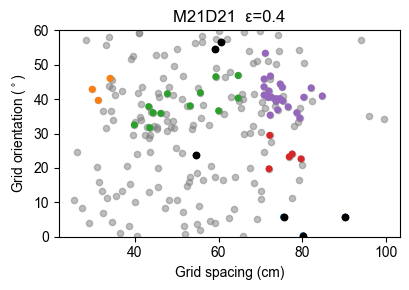

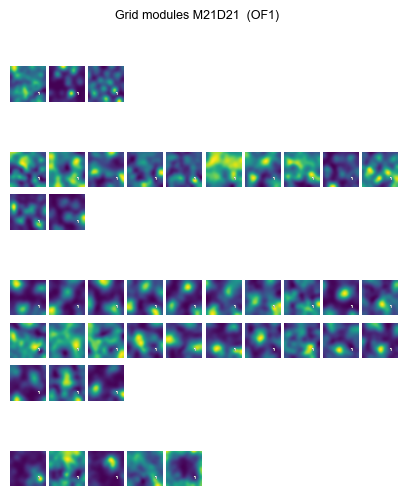

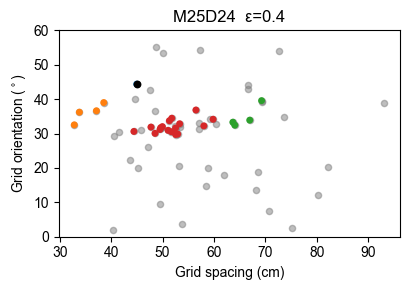

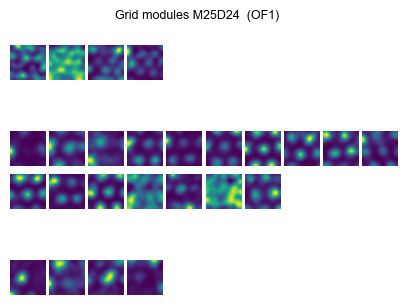

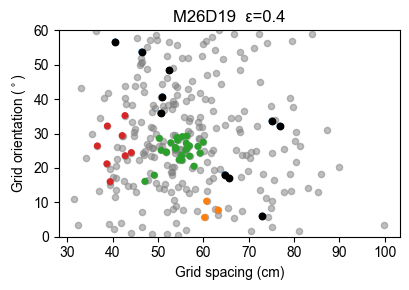

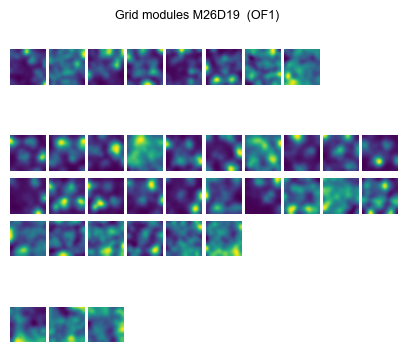

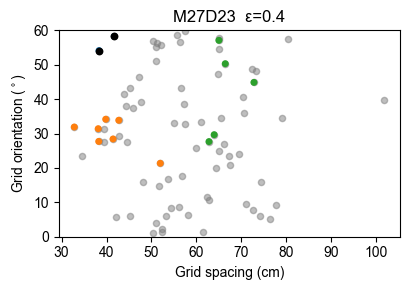

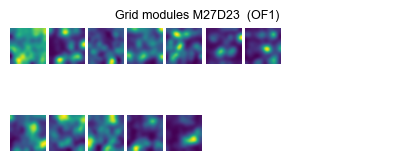

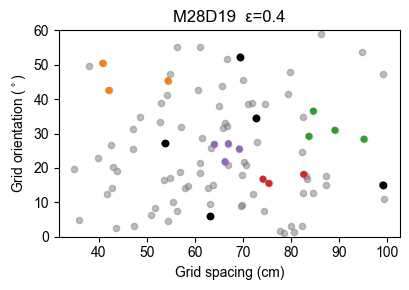

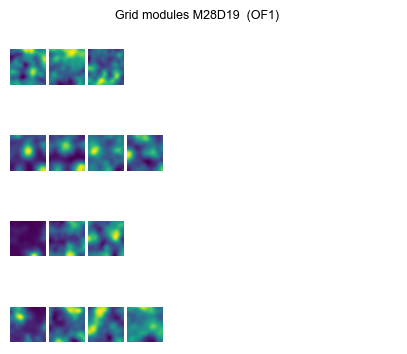

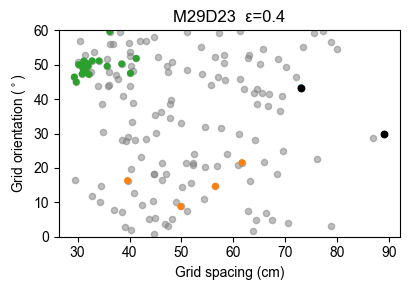

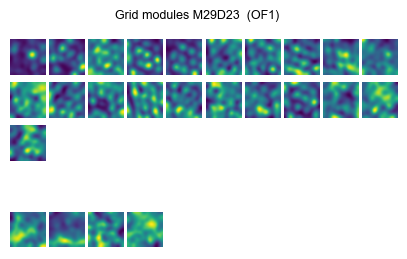

In [29]:
# loop over sessions and cluster grid cells with HDBSCAN
for mouse, days in mouse_days_to_plot.items():
    for day in days:
        gcs, ngs, all = classify_cells_both_sessions(mouse, day, percentile_threshold=95)
        grid_module_ids, grid_module_cluster_ids, _ = HDBSCAN_grid_modules(gcs, all, mouse=mouse, day=day, figpath='',
                                   cluster_selection_epsilon=0.4,
                                   min_cluster_size = 3,
                                   verbose=False,
                                   curate_with_vr=False, 
                                   curate_with_brain_region=False)

        # plot grid rate maps within their modules
        plot_grid_modules(gcs, grid_module_ids, grid_module_cluster_ids, 
                          mouse=mouse, day=day, figpath='', verbose=False)
